In [2]:
%pip install numpy
%pip install mpltern

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [9]:
def load_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    derived_df = df['derived'].apply(pd.Series)
    return derived_df

In [33]:
fn_human = "../../data/adipose_Jaitin2019/evidence_deg/evidence22.json"
fn_deg = "../../data/adipose_Jaitin2019/evidence_deg/evidence55.json"

fn_title1 = "Adipose Jaitin Batch 22"
fn_title2 = "Adipose Jaitin Batch 55"

derived_human_ev = load_evidence(fn_human)
deg_ev = load_evidence(fn_deg)

## Set Operations

In [34]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return set_diff_vals(a,b).shape[0]
def set_diff_vals(a,b):
    return np.setdiff1d(a,b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

## Global Gene Comparison

In [36]:
feature = "feature_identifier"

first = pd.Series(derived_human_ev[feature].str.strip().str.upper().unique()).dropna().tolist()
second = pd.Series(deg_ev[feature].str.strip().str.upper().unique()).dropna().tolist()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

120 36 36 ['ENSG00000018280' 'ENSG00000049860' 'ENSG00000074416' 'ENSG00000074966'
 'ENSG00000075234' 'ENSG00000100292' 'ENSG00000100311' 'ENSG00000103811'
 'ENSG00000105369' 'ENSG00000109471' 'ENSG00000112486' 'ENSG00000117281'
 'ENSG00000128040' 'ENSG00000128294' 'ENSG00000135549' 'ENSG00000135929'
 'ENSG00000138061' 'ENSG00000138795' 'ENSG00000139187' 'ENSG00000143184'
 'ENSG00000145220' 'ENSG00000161921' 'ENSG00000163564' 'ENSG00000164543'
 'ENSG00000166068' 'ENSG00000166278' 'ENSG00000169442' 'ENSG00000172116'
 'ENSG00000172215' 'ENSG00000175857' 'ENSG00000175899' 'ENSG00000183918'
 'ENSG00000186854' 'ENSG00000196126' 'ENSG00000204577' 'ENSG00000237541']


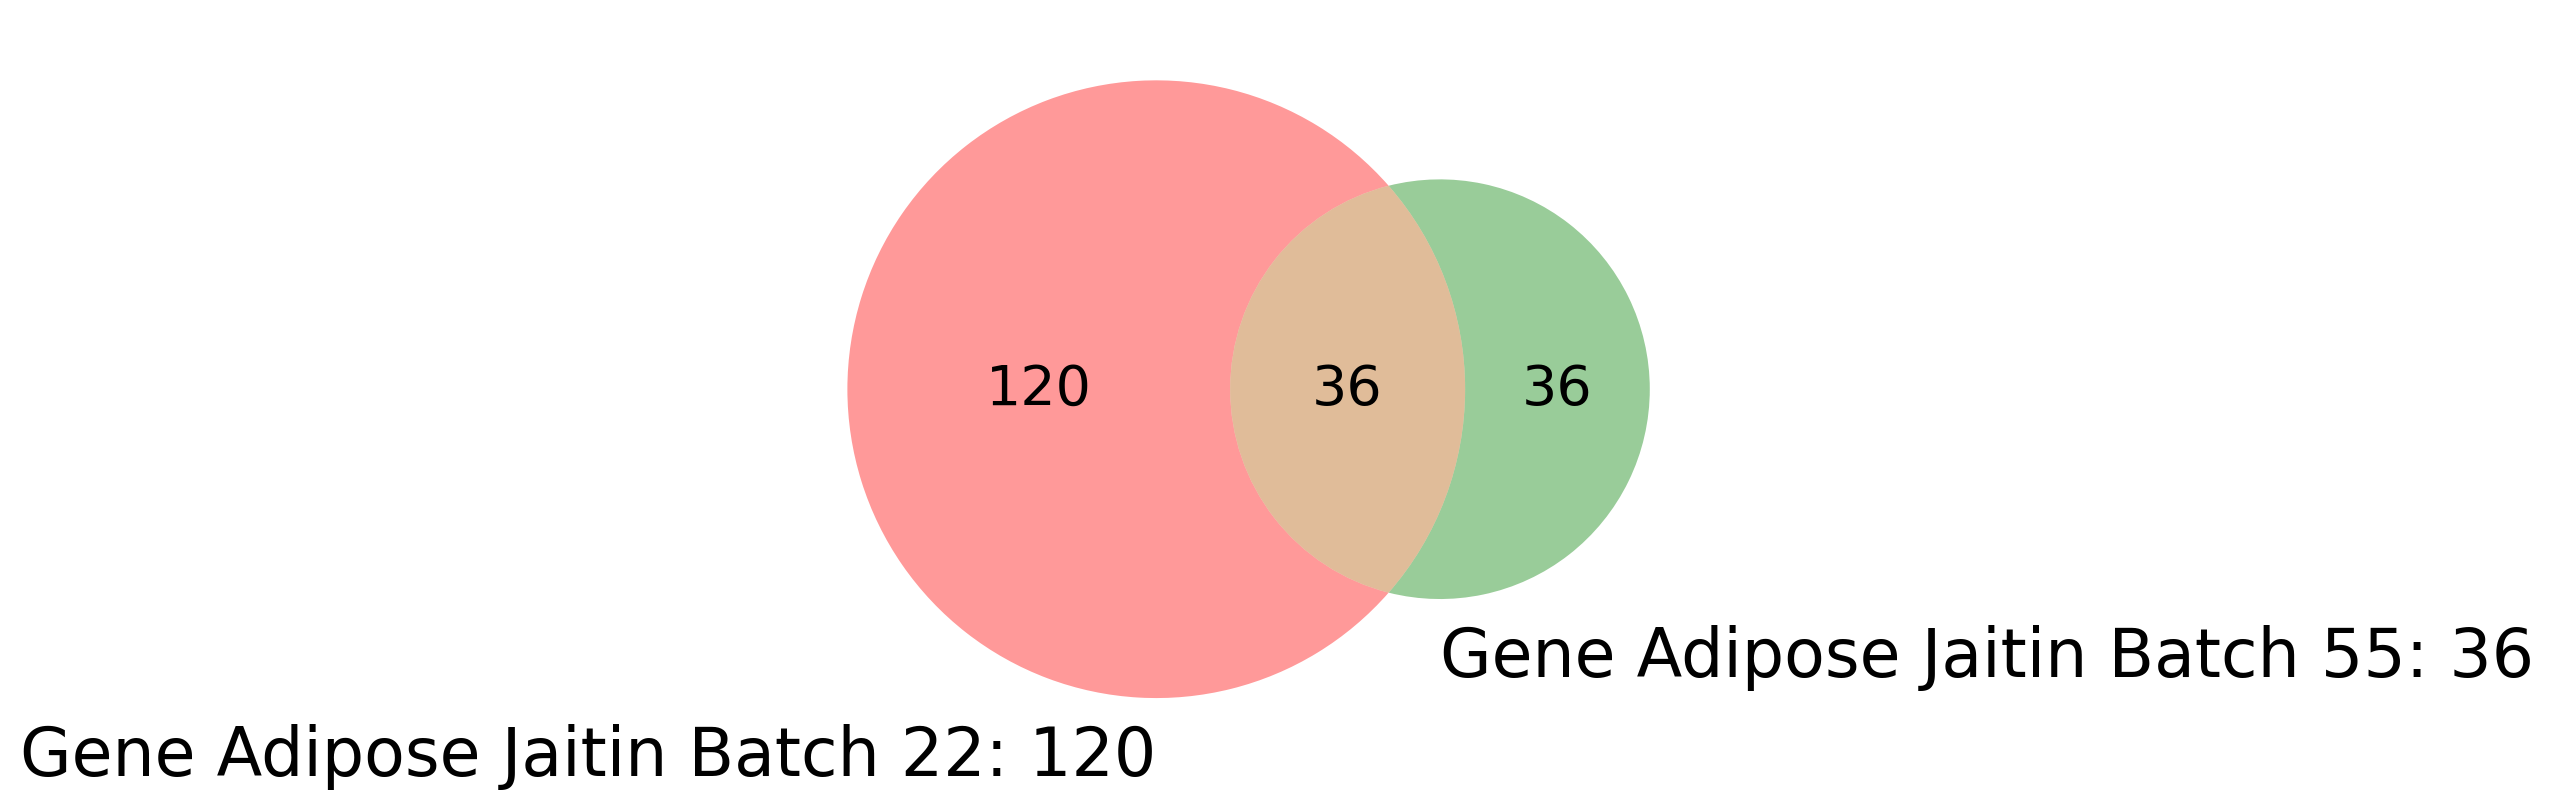

In [37]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene {fn_title1}: {left}', f'Gene {fn_title2}: {right}')

## Global Celltype Comparison

In [38]:
def get_standard_labels(labels):
    """
    Returns the standardized labels of cell type labels using a global map
    """

    with open('../cell_type_label_map.json', 'r') as file:
        map_dict = json.load(file)
        corrected_labels = []
        for l in list(map(str.upper,labels)):
            added = False
            for key, vals in map_dict.items():
                if l in vals or l == key:
                    corrected_labels.append(key)
                    added = True
            if not added:
                corrected_labels.append(l)
    return np.array(corrected_labels)


In [39]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create

first = derived_human_ev[feature].str.strip().str.upper().unique()
first = get_standard_labels(first)
second = deg_ev[feature].str.strip().str.upper().unique()
second = get_standard_labels(second)

left  = set_diff(first, second)
left_vals = set_diff_vals(first, second)

itx   = set_itx(first, second)
itx_vals = set_itx_vals(first, second)

right = set_diff(second, first)
right_vals = set_diff_vals(second, first)

print(left, left_vals)
print(itx, itx_vals)
print(right, right_vals)

0 []
8 ['B' 'CD8 T' 'LAM' 'MAC' 'MON' 'NAIVE T' 'NEUT' 'NK']
0 []


0 8 0 ['B' 'CD8 T' 'LAM' 'MAC' 'MON' 'NAIVE T' 'NEUT' 'NK']


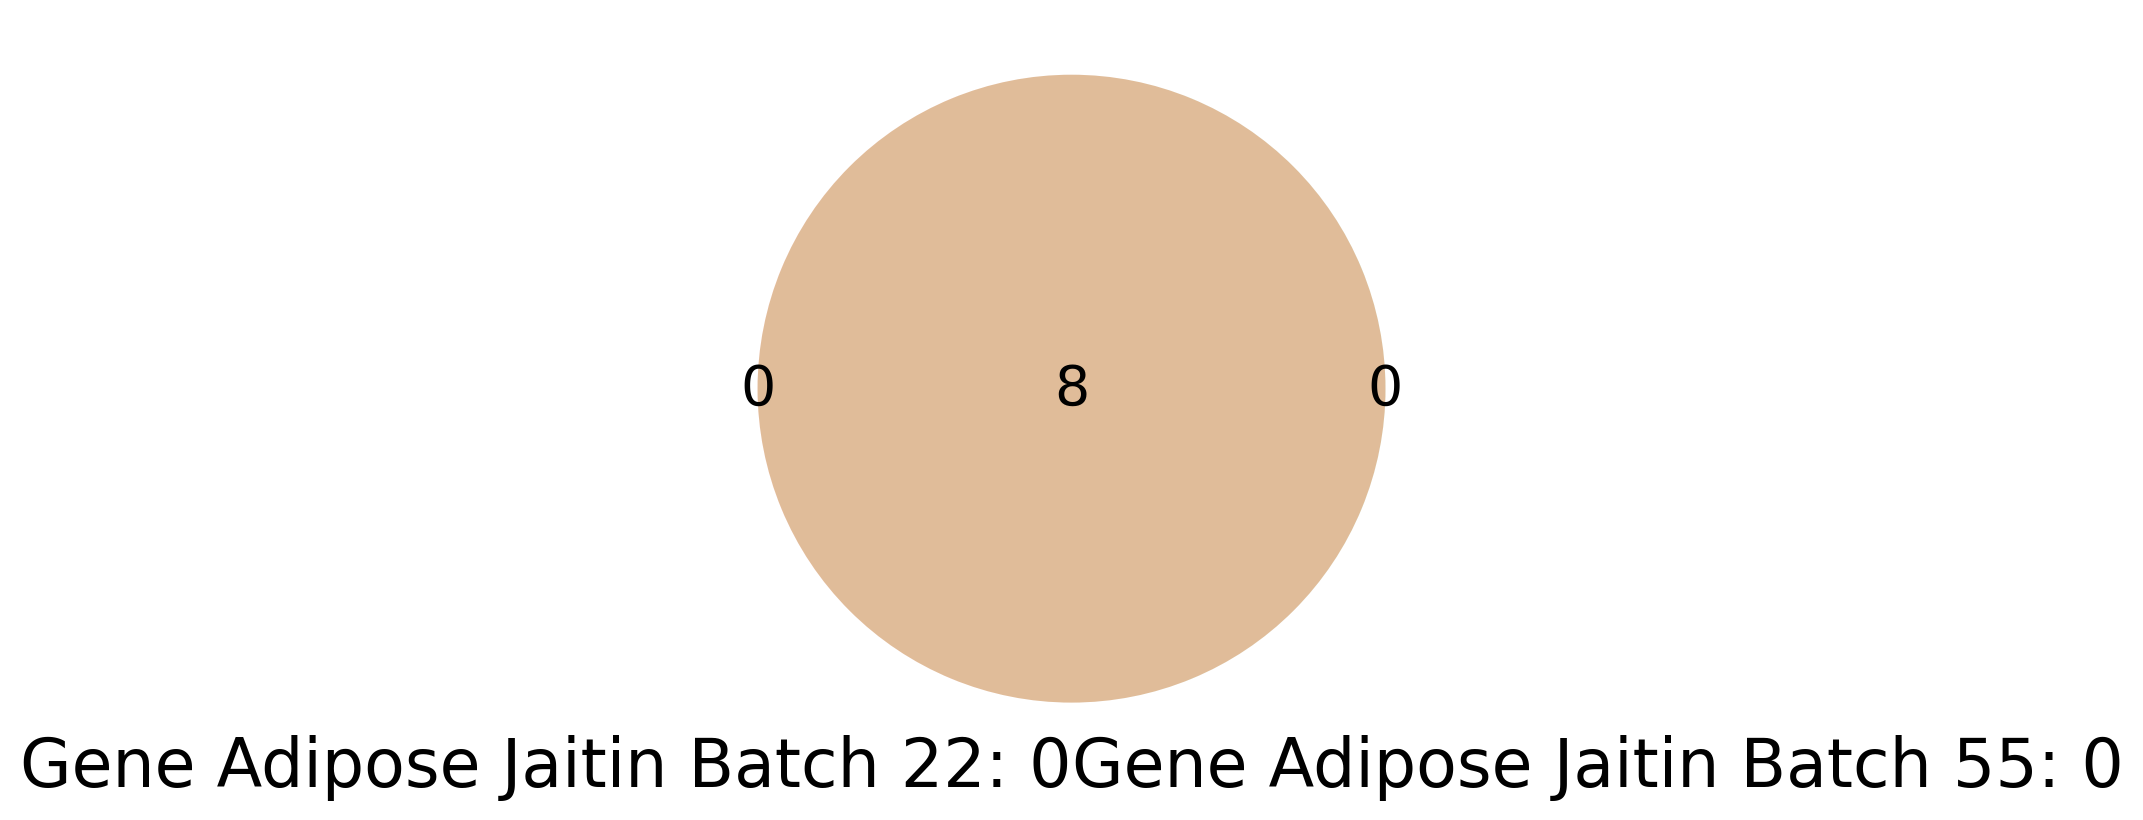

In [40]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene {fn_title1}: {left}', f'Gene {fn_title2}: {right}')

## Set Difference + Intersection of Gene Expression Between All Cells in Evidence Deg and Evidence Human

In [41]:
def get_label(og_label):
    with open('../cell_type_label_map.json', 'r') as file:
        map_dict = json.load(file)

    for key, vals in map_dict.items():
        if og_label in vals or og_label == key:
            return key
    return og_label  

In [42]:
def make_3d_matrix(human_fn, deg_fn):
    """
    Finds similarites in gene expression between all cells mentioned in evidence deg and evidence human and returns a 3D matrix describing the left difference, intersection, and right difference in gene expression.

    Returns:
        pd.DataFrame: the 3D matrix describing set difference and intersection in gene expression
    """

    human_ev = load_evidence(human_fn) # gets only the derived part of evidence.json in evidence_human
    deg_ev = load_evidence(deg_fn) 

    feature = "cell_type_label"

    
    human_ev[feature] = pd.Series(human_ev[feature].str.strip().str.upper()).apply(lambda x: get_label(x))
    deg_ev[feature] = pd.Series(deg_ev[feature].str.strip().str.upper()).apply(lambda x: get_label(x))
    
    # x axis is human evidence and y axis is deg evidence

    x_labels = sorted(human_ev[feature].unique())
    y_labels = sorted(deg_ev[feature].unique())

    result_df = pd.DataFrame(index = x_labels, columns=y_labels, dtype=object)

    for x in x_labels:
        for y in y_labels:
            genes1 = set(human_ev[human_ev[feature] == x]['feature_identifier'])
            genes2 = set(deg_ev[deg_ev[feature] == y]['feature_identifier'])

            left_diff = genes1 - genes2
            intersection = genes1 & genes2
            right_diff = genes2 - genes1

            result_df.loc[x,y] = [left_diff, intersection, right_diff]

    return result_df

In [43]:
fn1 = "../../data/adipose_Jaitin2019/evidence_deg/evidence.json"
fn2 = "../../data/adipose_Jaitin2019/evidence_deg/evidence22.json"
matrix = make_3d_matrix(fn1, fn2)

## Find Left Difference, Intersection, Right Difference Between Cells

In [44]:
def cell_intersection_stats_numpy(matrix):
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    vals = np.zeros((matrix.shape[0], matrix.shape[1], 3))
    rowids = matrix.index
    colids = matrix.columns
    for ridx, index in enumerate(matrix.index):
        for cidx, value in enumerate(matrix.columns):
            left = len(matrix.loc[index, value][0])
            intersection = len(matrix.loc[index, value][1])
            right = len(matrix.loc[index, value][2])
            # intersection_df.loc[index, value] = [left, intersection, right]
            # vals[ridx, cidx, 0] = left
            vals[ridx, cidx,:,] = [left, intersection, right]

    
    return (vals, rowids, colids)


In [24]:
def cell_intersection_stats(matrix):
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    for index in matrix.index:
        for value in matrix.columns:
            left = len(matrix.loc[index, value][0])
            intersection = len(matrix.loc[index, value][1])
            right = len(matrix.loc[index, value][2])
            intersection_df.loc[index, value] = [left, intersection, right]
    
    return intersection_df

In [45]:
cell_similarity_matrix = cell_intersection_stats(matrix)
# before making vals, make sure the rows and columns are sorted correctly
(vals, rowids, colids) = cell_intersection_stats_numpy(matrix)

In [46]:
left = np.diag(vals[:,:,0])
itx = np.diag(vals[:,:,1])
right = np.diag(vals[:,:,2])

/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_60213/701868648.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_axis, rotation=90, fontsize=8)
/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_60213/701868648.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


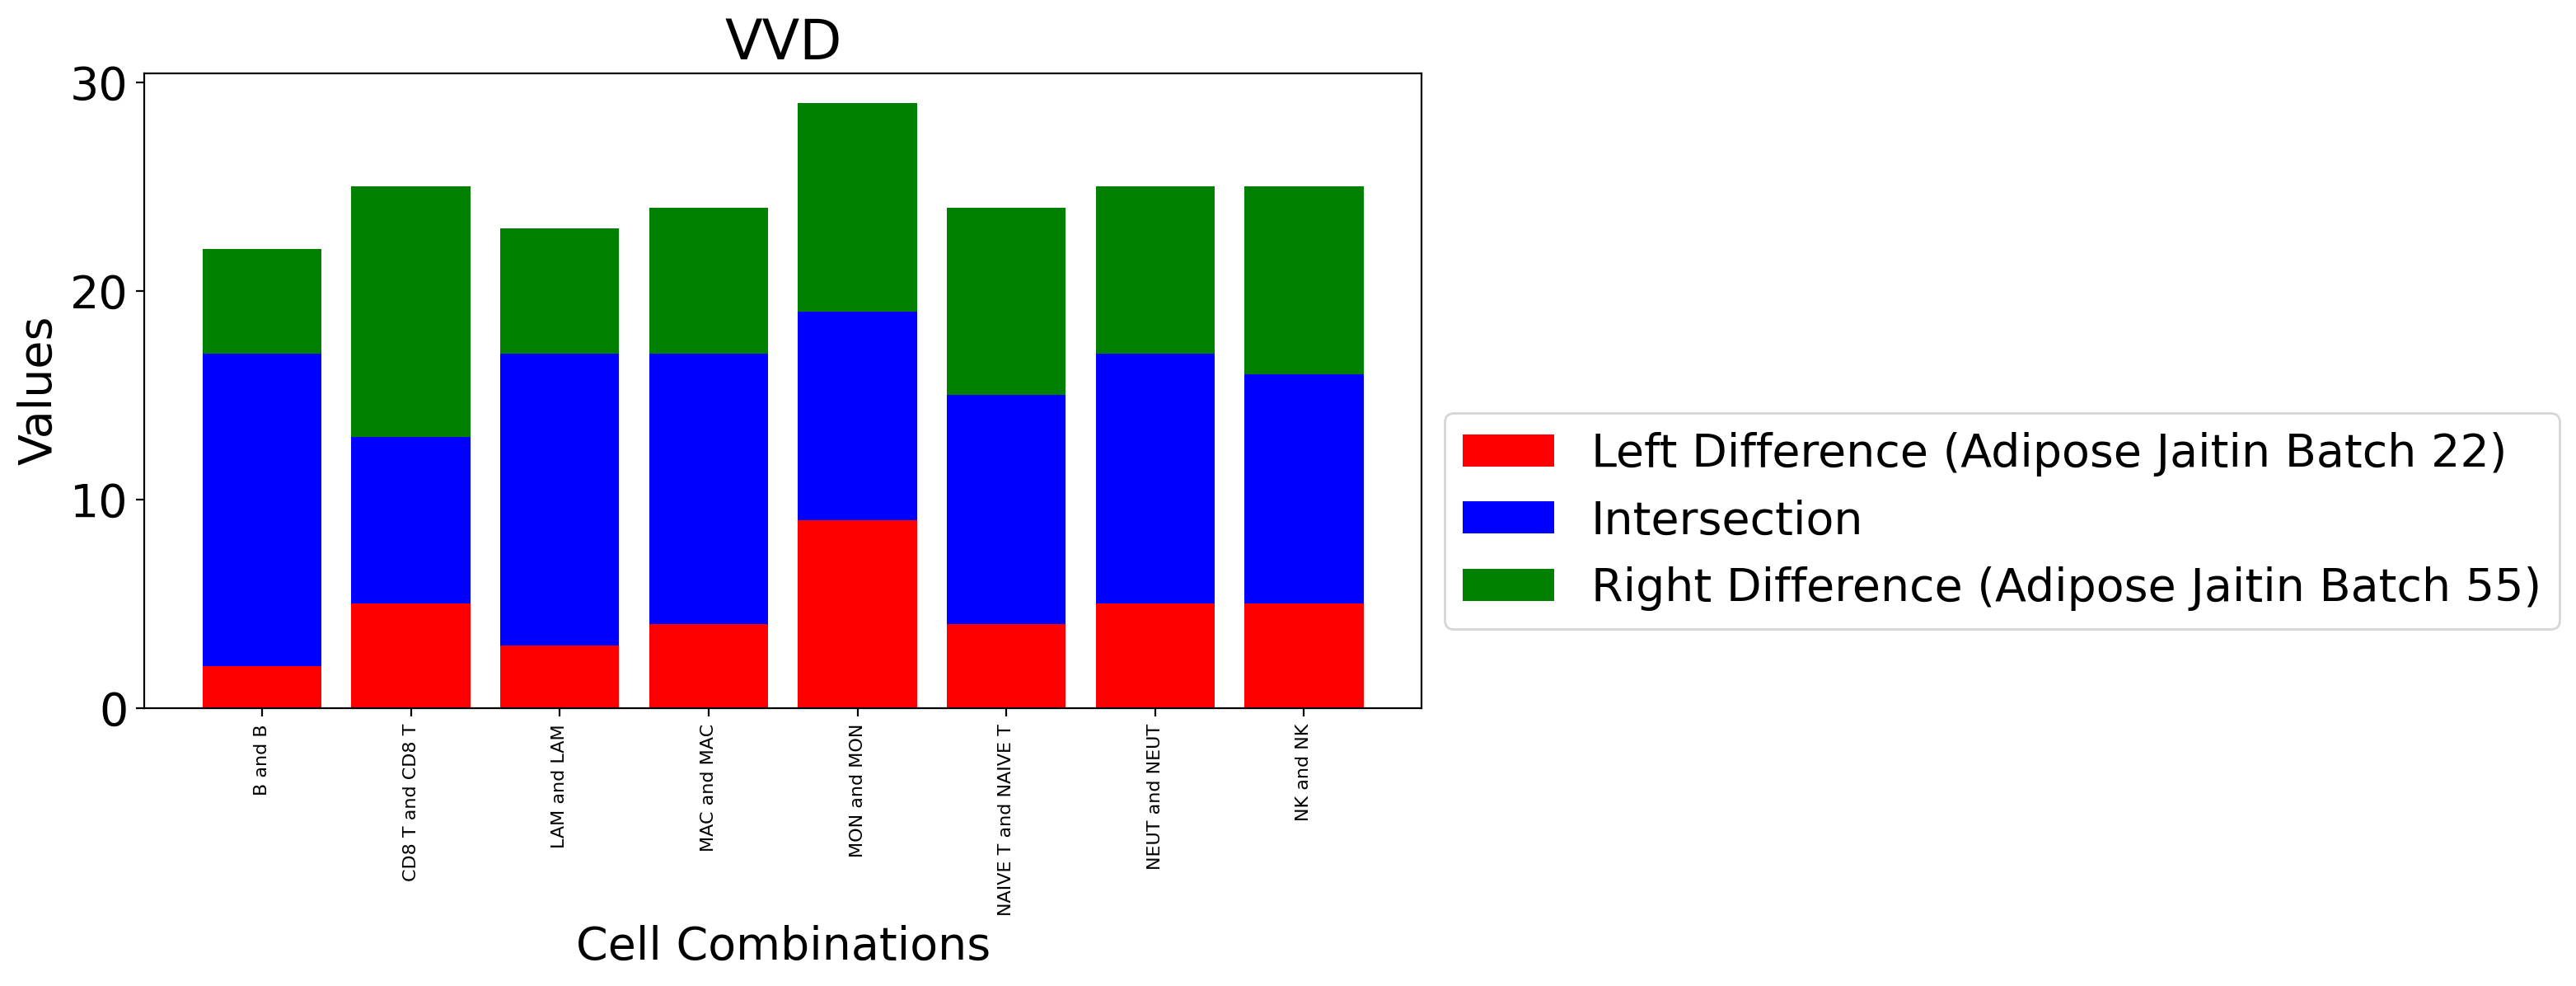

In [48]:
fig, ax = plt.subplots(figsize=(10,5))

left = np.diag(vals[:,:,0])
itx = np.diag(vals[:,:,1])
right = np.diag(vals[:,:,2])

y1 = left 
y2 = itx 
y3 = right 

human_cells = cell_similarity_matrix.index
df_cells = cell_similarity_matrix.columns

x_axis = np.array([f"{h} and {d}" for h, d in itertools.product(human_cells, df_cells) if h == d])

ax.bar(x_axis, y1, color='r', label=f'Left Difference ({fn_title1})')
ax.bar(x_axis, y2, bottom=y1, color='b', label='Intersection')
ax.bar(x_axis, y3, bottom=y1+y2, color='g', label=f'Right Difference ({fn_title2})')

ax.set_xticklabels(x_axis, rotation=90, fontsize=8)

ax.set(
    **{
        "xlabel" : "Cell Combinations",
        "ylabel": "Values",
        "title": "VVD"
    }
)
ax.legend(bbox_to_anchor=(1,0.5))

# Show the plot
fig.show()


## VVD (Percentage Version)

/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_60213/682196842.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_axis, rotation=90, fontsize=8)
/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_60213/682196842.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


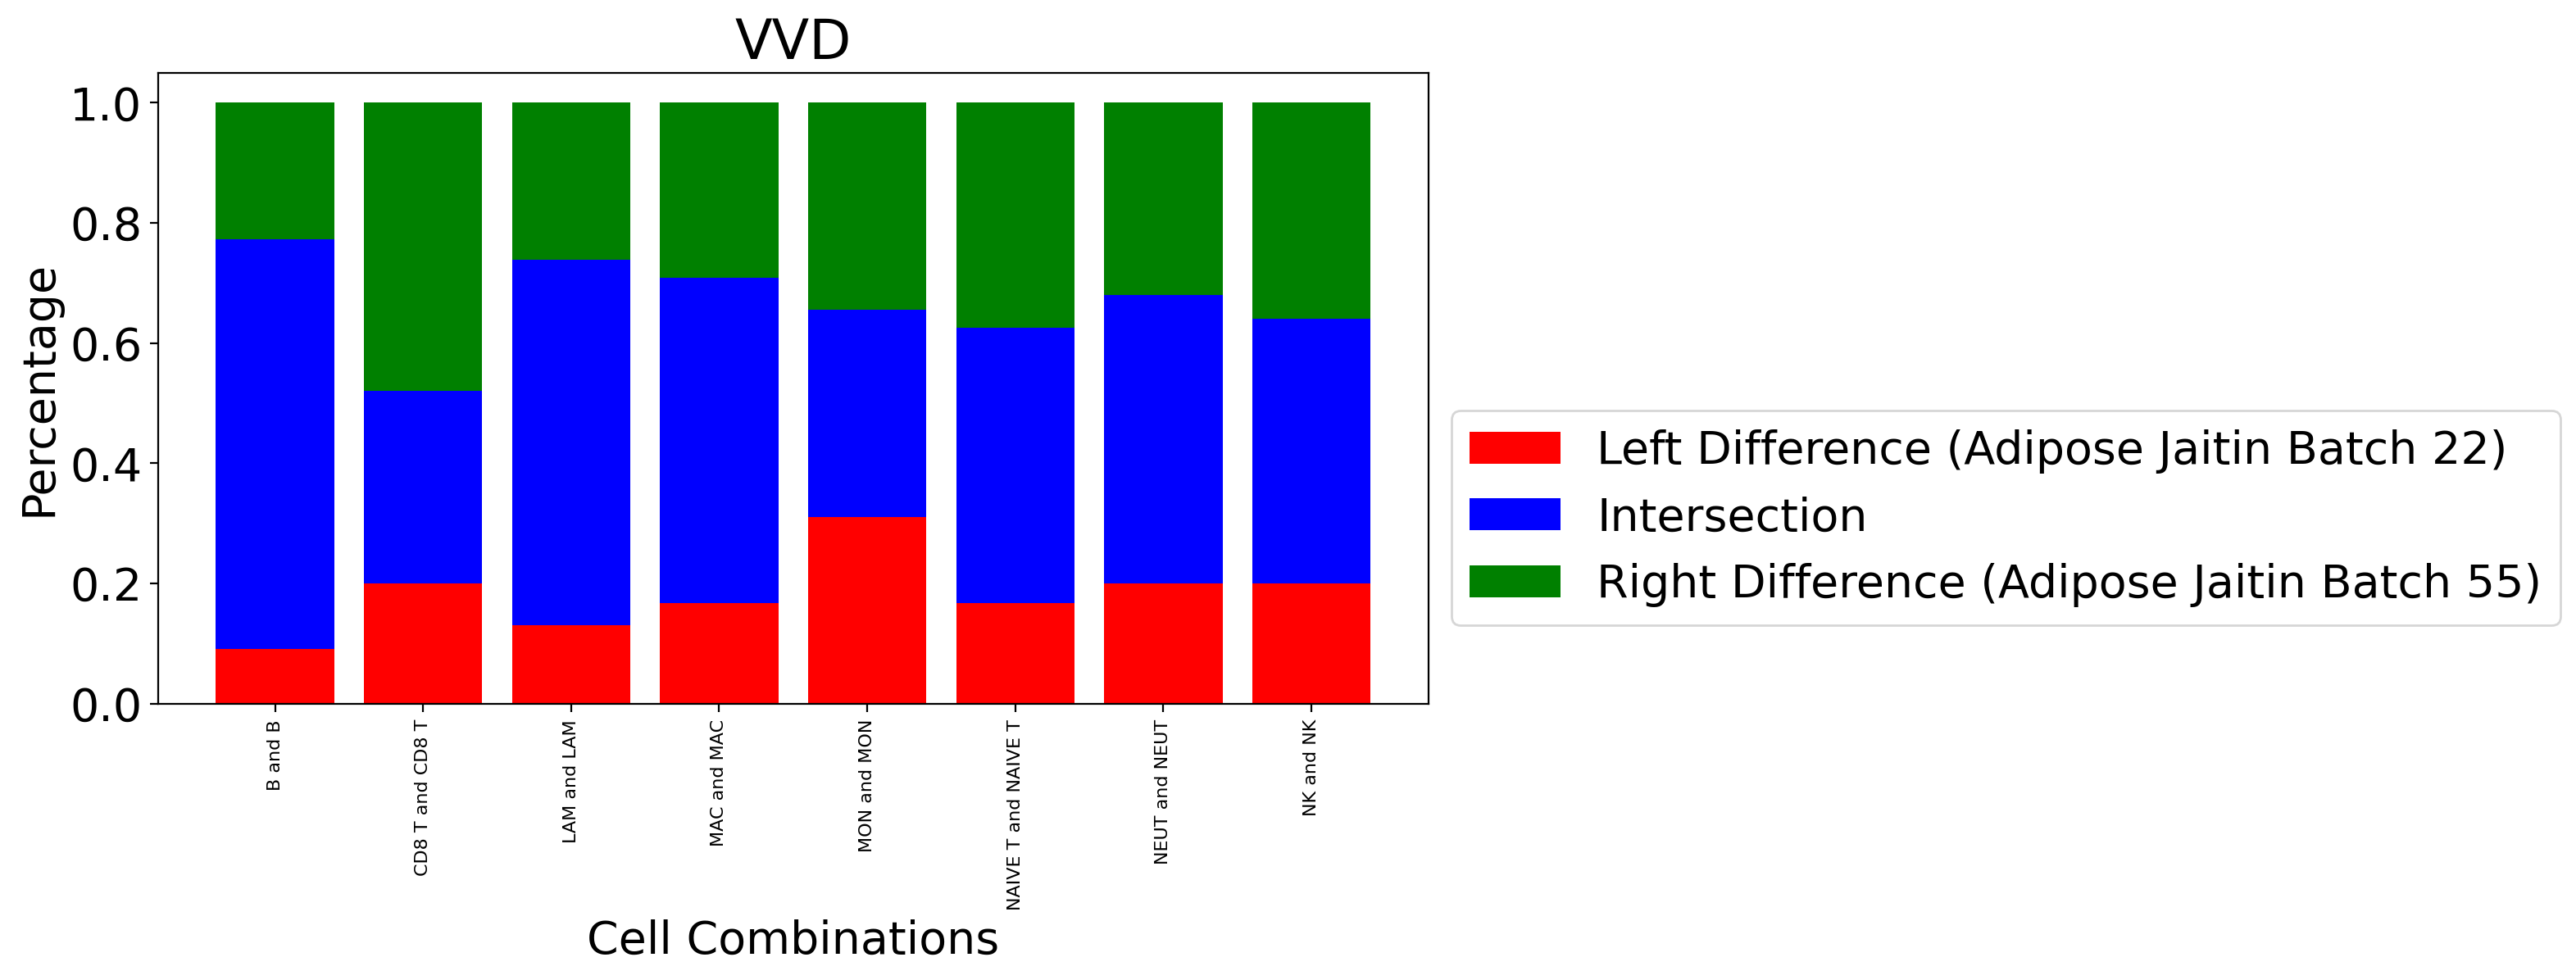

In [49]:
fig, ax = plt.subplots(figsize=(10,5))

total = np.diag(vals[:,:,0] + vals[:,:,1] + vals[:,:,2])

left = np.diag(vals[:,:,0]/total)
itx = np.diag(vals[:,:,1]/total)
right = np.diag(vals[:,:,2]/total)

y1 = left 
y2 = itx 
y3 = right 

human_cells = cell_similarity_matrix.index
df_cells = cell_similarity_matrix.columns

x_axis = np.array([f"{h} and {d}" for h, d in itertools.product(human_cells, df_cells) if h == d])

ax.bar(x_axis, y1, color='r', label=f'Left Difference ({fn_title1})')
ax.bar(x_axis, y2, bottom=y1, color='b', label='Intersection')
ax.bar(x_axis, y3, bottom=y1+y2, color='g', label=f'Right Difference ({fn_title2})')

ax.set_xticklabels(x_axis, rotation=90, fontsize=8)

ax.set(
    **{
        "xlabel" : "Cell Combinations",
        "ylabel": "Percentage",
        "title": "VVD"
    }
)
ax.legend(bbox_to_anchor=(1,0.5))

# Show the plot
fig.show()

## Ternary Plots

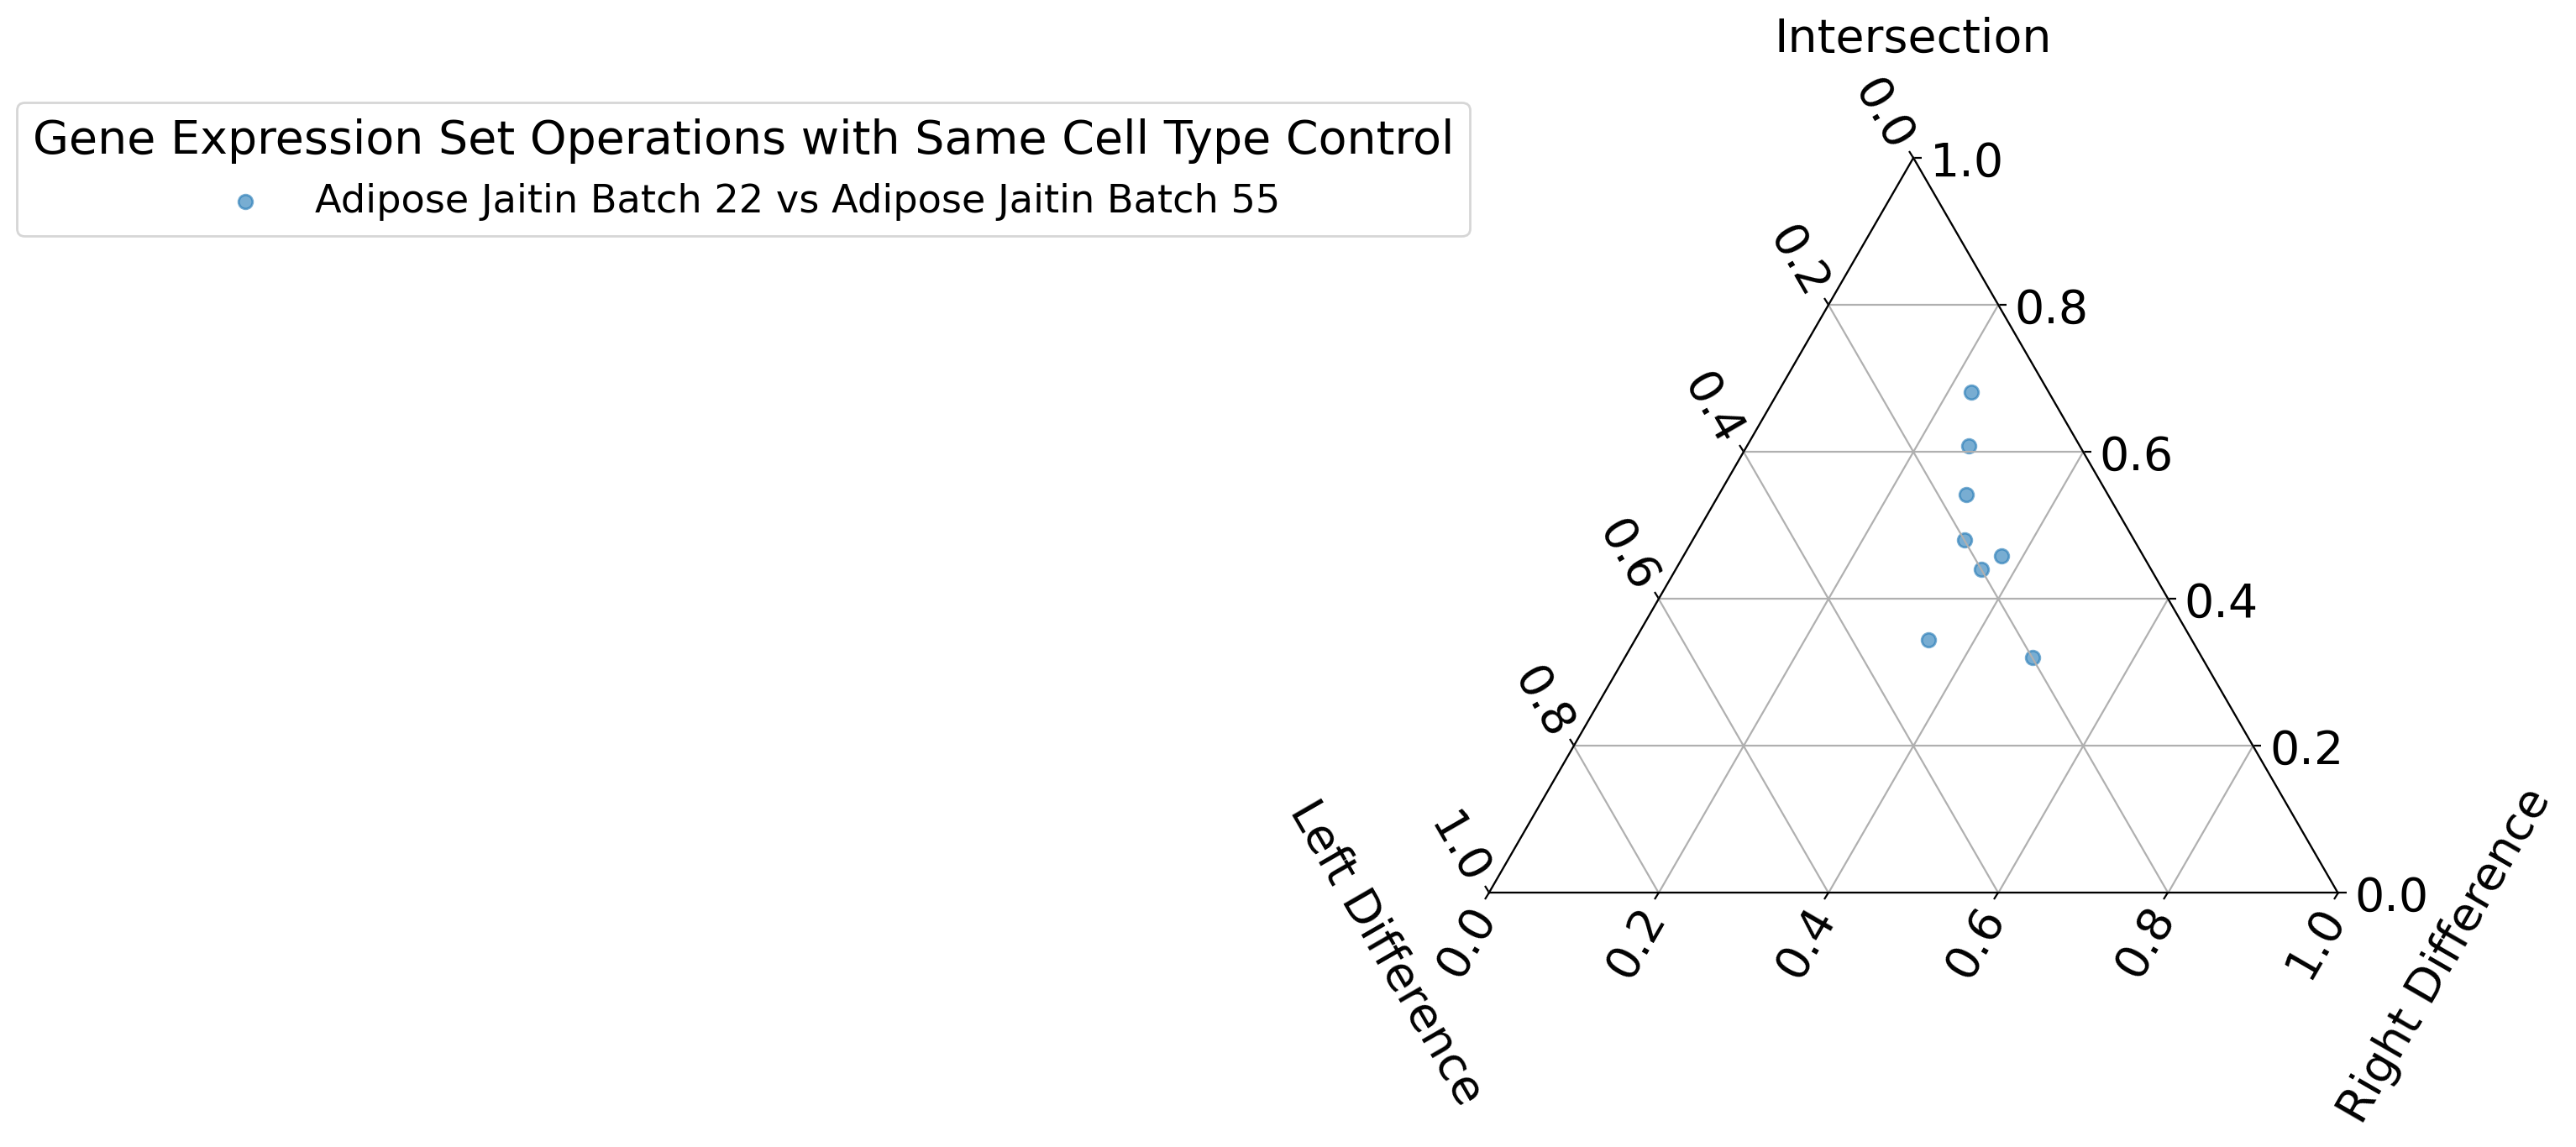

In [71]:
np.random.seed(seed=19)
t0, l0, r0 = np.random.dirichlet(alpha=(2.0, 2.0, 2.0), size=100).T

np.random.seed(seed=68)
t1, l1, r1 = np.random.dirichlet(alpha=(2.0, 2.0, 2.0), size=100).T

dt = t1 - t0
dl = l1 - l0
dr = r1 - r0

fig = plt.figure(figsize=(15, 15))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 2, 1, projection="ternary")
pc = ax.scatter(itx, left, right, alpha = 0.6, label = f"{fn_title1} vs {fn_title2}") # top, left, right

ax.grid(visible=  True, axis = 'both')

ax.set_tlabel('Intersection')
ax.set_llabel('Left Difference')
ax.set_rlabel('Right Difference')

ax.legend(title = "Gene Expression Set Operations with Same Cell Type Control", fontsize = 'small', bbox_to_anchor=(0, 1, 0, .102))

plt.show()

## Gene Expression Comparison Between Different Cells

In [82]:
batch1_fn = "../../data/adipose_Jaitin2019/evidence_deg/evidence55.json"
batch2_fn = "../../data/adipose_Jaitin2019/evidence_deg/evidence.json"

matrix = make_3d_matrix(batch1_fn, batch2_fn)

(vals, rowids, colids) = cell_intersection_stats_numpy(matrix)
inter_stats = cell_intersection_stats(matrix)

df_no_diag = inter_stats.mask(np.eye(inter_stats.shape[0], dtype=bool))

df_no_diag


,B,CD8 T,LAM,MAC,MON,NAIVE T,NEUT,NK
B,NaN,"[9, 0, 13]","[9, 0, 17]","[9, 0, 17]","[9, 0, 19]","[9, 0, 15]","[9, 0, 17]","[9, 0, 16]"
CD8 T,"[9, 0, 17]",NaN,"[9, 0, 17]","[9, 0, 17]","[9, 0, 19]","[9, 0, 15]","[9, 0, 17]","[9, 0, 16]"
LAM,"[9, 0, 17]","[9, 0, 13]",NaN,"[9, 0, 17]","[9, 0, 19]","[9, 0, 15]","[9, 0, 17]","[9, 0, 16]"
MAC,"[9, 0, 17]","[9, 0, 13]","[9, 0, 17]",NaN,"[9, 0, 19]","[9, 0, 15]","[9, 0, 17]","[9, 0, 16]"
MON,"[9, 0, 17]","[9, 0, 13]","[9, 0, 17]","[9, 0, 17]",NaN,"[9, 0, 15]","[9, 0, 17]","[9, 0, 16]"
NAIVE T,"[9, 0, 17]","[9, 0, 13]","[9, 0, 17]","[9, 0, 17]","[9, 0, 19]",NaN,"[9, 0, 17]","[9, 0, 16]"
NEUT,"[9, 0, 17]","[9, 0, 13]","[9, 0, 17]","[9, 0, 17]","[9, 0, 19]","[9, 0, 15]",NaN,"[9, 0, 16]"
NK,"[9, 0, 17]","[9, 0, 13]","[9, 0, 17]","[9, 0, 17]","[9, 0, 19]","[9, 0, 15]","[9, 0, 17]",NaN


### make vvds for comparisons done between different cells

/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_31027/3958494463.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_axis, rotation=90, fontsize=8)
/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_31027/3958494463.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


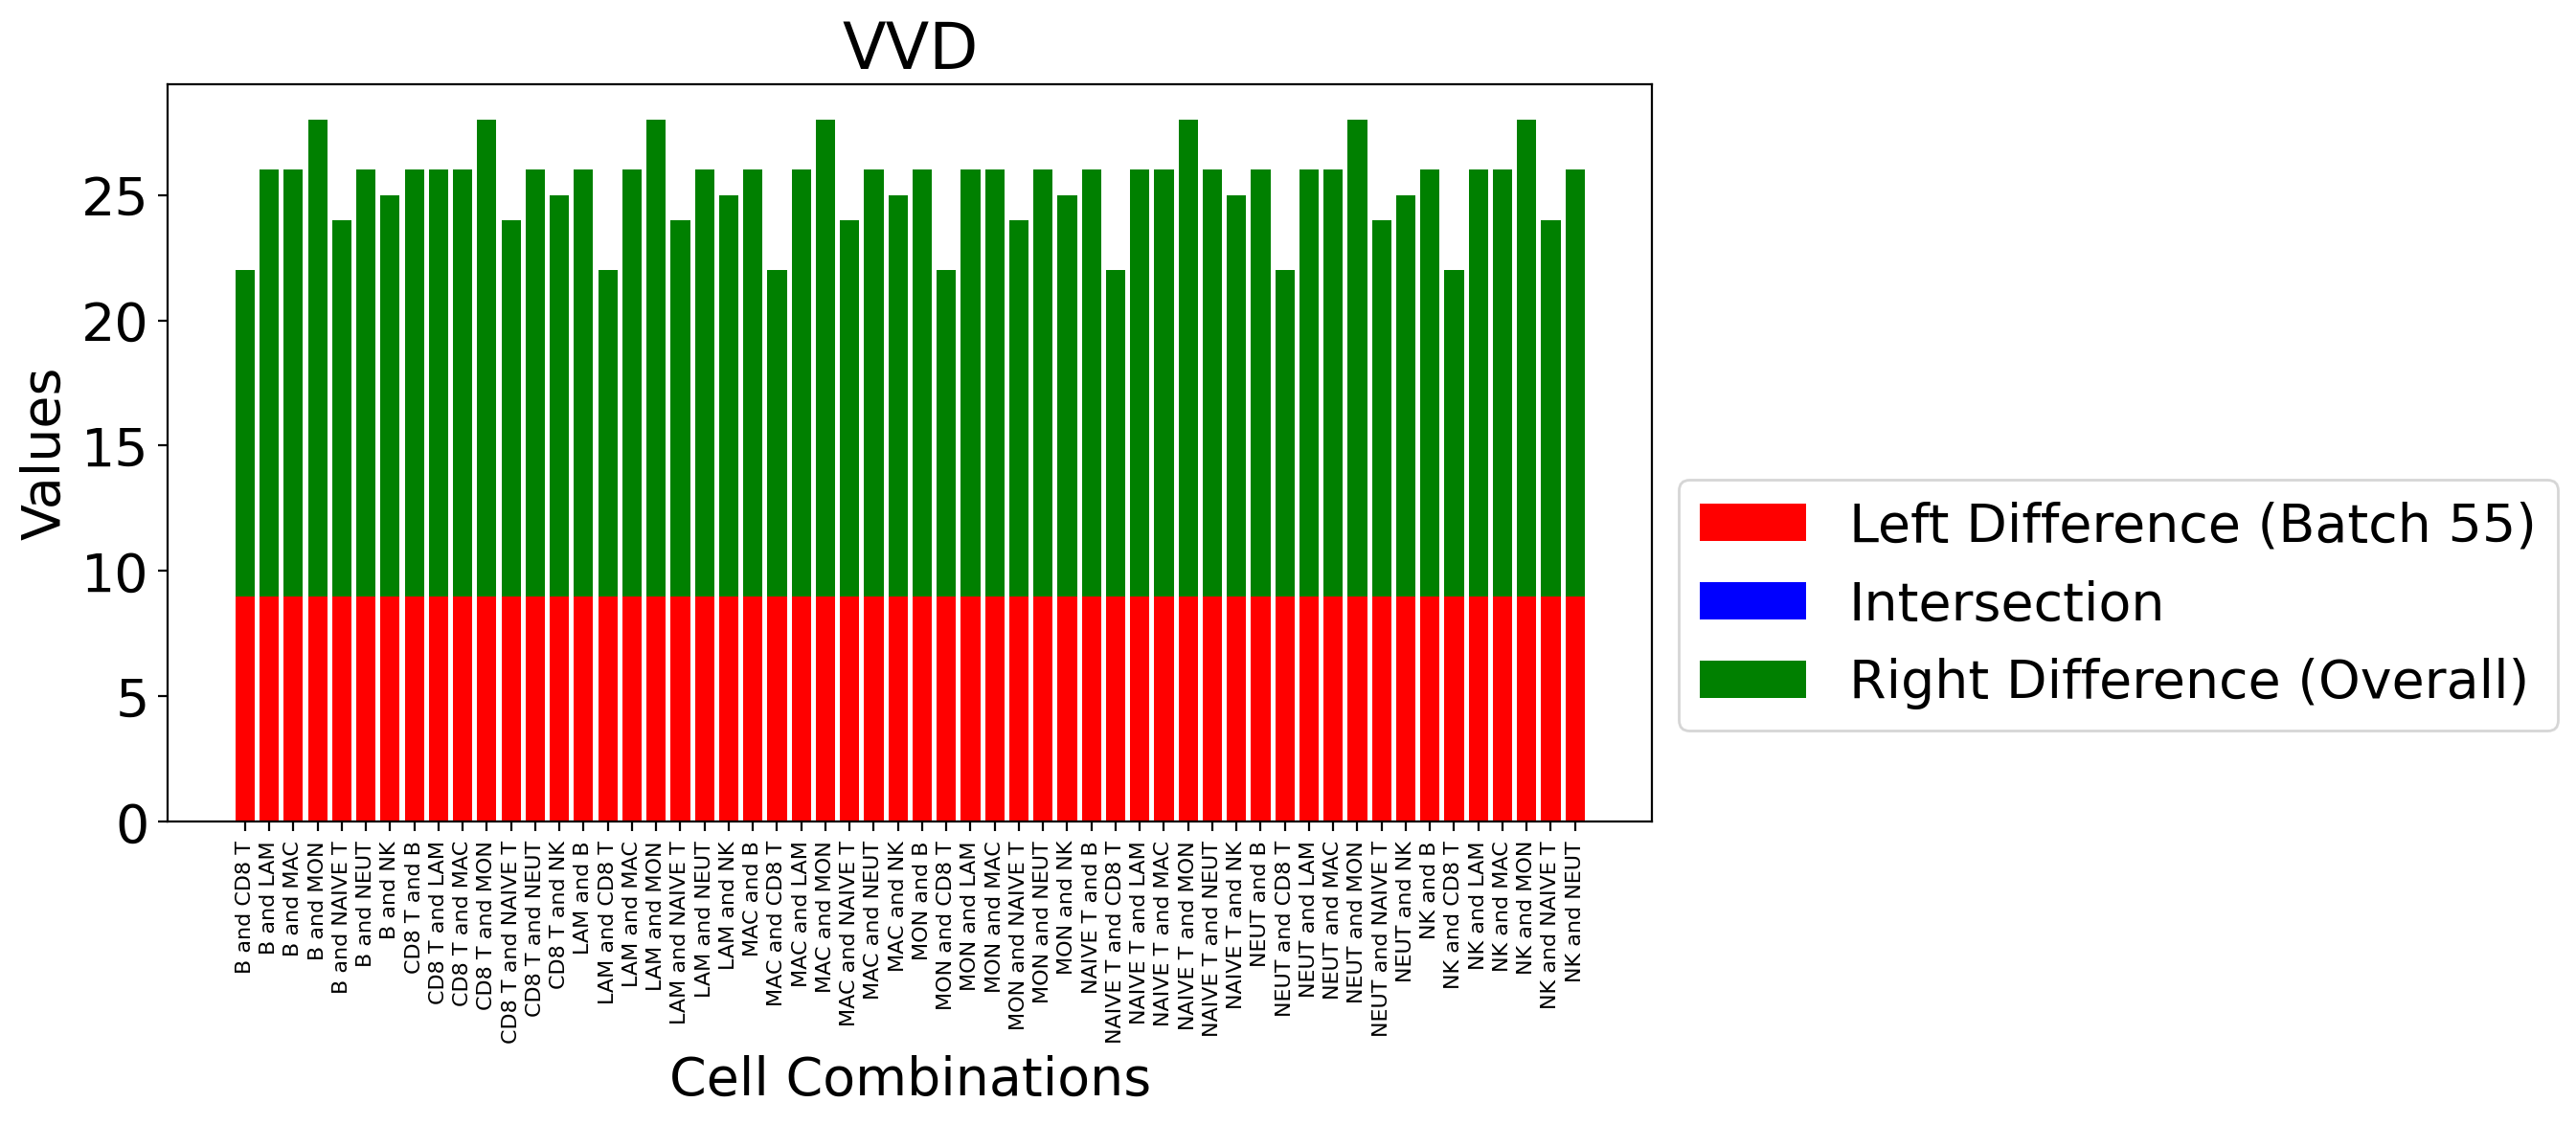

In [83]:
fig, ax = plt.subplots(figsize=(10,5))

y1 = vals[:,:,0]
y1 = y1[~np.eye(y1.shape[0], dtype=bool)]

y2 = vals[:,:,1]
y2 = y2[~np.eye(y2.shape[0], dtype = bool)]

y3 = vals[:,:,2]
y3 = y3[~np.eye(y3.shape[0], dtype=bool)]

x_cells = df_no_diag.index
y_cells = df_no_diag.columns

x_axis = [f"{h} and {d}" for h, d in itertools.product(x_cells, y_cells) if h != d]

ax.bar(x_axis, y1, color='r', label='Left Difference (Batch 55)')
ax.bar(x_axis, y2, bottom=y1, color='b', label='Intersection')
ax.bar(x_axis, y3, bottom=y1+y2, color='g', label='Right Difference (Overall)')

ax.set_xticklabels(x_axis, rotation=90, fontsize=8)

ax.set(
    **{
        "xlabel" : "Cell Combinations",
        "ylabel": "Values",
        "title": "VVD"
    }
)
ax.legend(bbox_to_anchor=(1,0.5))

# Show the plot
fig.show()



In [47]:
def get_similar_cells():
    result = []
    for index in cell_similarity_matrix.index:
        for value in cell_similarity_matrix.columns:
            if cell_similarity_matrix.loc[index, value]:
                result.append([index, value])
    return result


In [48]:
get_similar_cells()

[['ADIPOCYTE', 'ADIPOCYTE'],
 ['ADIPOCYTE', 'B CELL'],
 ['ADIPOCYTE', 'DENDRITIC CELL'],
 ['ADIPOCYTE', 'ENDOMETRIUM'],
 ['ADIPOCYTE', 'ENDOTHELIUM'],
 ['ADIPOCYTE', 'HPLASMABLAST'],
 ['ADIPOCYTE', 'HUMAN ASPCS'],
 ['ADIPOCYTE', 'MACROPHAGE'],
 ['ADIPOCYTE', 'MAST_CELL'],
 ['ADIPOCYTE', 'MESOTHELIUM'],
 ['ADIPOCYTE', 'MONOCYTE'],
 ['ADIPOCYTE', 'NATURAL KILLER CELL'],
 ['ADIPOCYTE', 'NEUTROPHIL'],
 ['ADIPOCYTE', 'PERICYTE'],
 ['ADIPOCYTE', 'SMOOTH MUSCLE CELLS'],
 ['ADIPOCYTE', 'T CELL'],
 ['B CELL', 'ADIPOCYTE'],
 ['B CELL', 'B CELL'],
 ['B CELL', 'DENDRITIC CELL'],
 ['B CELL', 'ENDOMETRIUM'],
 ['B CELL', 'ENDOTHELIUM'],
 ['B CELL', 'HPLASMABLAST'],
 ['B CELL', 'HUMAN ASPCS'],
 ['B CELL', 'MACROPHAGE'],
 ['B CELL', 'MAST_CELL'],
 ['B CELL', 'MESOTHELIUM'],
 ['B CELL', 'MONOCYTE'],
 ['B CELL', 'NATURAL KILLER CELL'],
 ['B CELL', 'NEUTROPHIL'],
 ['B CELL', 'PERICYTE'],
 ['B CELL', 'SMOOTH MUSCLE CELLS'],
 ['B CELL', 'T CELL'],
 ['DENDRITIC CELL', 'ADIPOCYTE'],
 ['DENDRITIC CELL', 'B CEL